# 🚗 DoorDash Delivery Prediction
## Notebook 01 — Exploratory Data Analysis (EDA)

**Goal:** Understand the dataset, spot patterns, and identify issues before cleaning.

**Author:** Divyargarg

---

In [1]:
# ── CELL 1: Import Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
# ── CELL 2: Load Data ─────────────────────────────────────────────────
df = pd.read_csv('../data/raw/historical_data.csv')

print(f'✅ Data loaded!')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Data loaded!
📊 Shape: 197428 rows × 16 columns


In [3]:
# ── CELL 3: First Look ────────────────────────────────────────────────
print('🔍 First 5 rows:')
df.head()

🔍 First 5 rows:


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.00,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.00,4,3441,4,557,1239,33.00,14.00,21.00,446,861.00
1,2.00,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.00,1,1900,1,1400,1400,1.00,2.00,2.00,446,690.00
2,3.00,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.00,1,1900,1,1900,1900,1.00,0.00,0.00,446,690.00
3,3.00,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.00,6,6900,5,600,1800,1.00,1.00,2.00,446,289.00
4,3.00,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.00,3,3900,3,1100,1600,6.00,6.00,9.00,446,650.00


In [4]:
# ── CELL 4: Last 5 Rows ───────────────────────────────────────────────
print('🔍 Last 5 rows:')
df.tail()

🔍 Last 5 rows:


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
197423,1.00,2015-02-17 00:19:41,2015-02-17 01:24:48,2956,fast,4.00,3,1389,3,345,649,17.00,17.00,23.00,251,331.00
197424,1.00,2015-02-13 00:01:59,2015-02-13 00:58:22,2956,fast,4.00,6,3010,4,405,825,12.00,11.00,14.00,251,915.00
197425,1.00,2015-01-24 04:46:08,2015-01-24 05:36:16,2956,fast,4.00,5,1836,3,300,399,39.00,41.00,40.00,251,795.00
197426,1.00,2015-02-01 18:18:15,2015-02-01 19:23:22,3630,sandwich,1.00,1,1175,1,535,535,7.00,7.00,12.00,446,384.00
197427,1.00,2015-02-08 19:24:33,2015-02-08 20:01:41,3630,sandwich,1.00,4,2605,4,425,750,20.00,20.00,23.00,446,134.00


In [5]:
# ── CELL 5: Column Names & Data Types ────────────────────────────────
print(f"{'Column':<40} {'Type':<15}")
print('-' * 55)
for col in df.columns:
    print(f"{col:<40} {str(df[col].dtype):<15}")

Column                                   Type           
-------------------------------------------------------
market_id                                float64        
created_at                               str            
actual_delivery_time                     str            
store_id                                 int64          
store_primary_category                   str            
order_protocol                           float64        
total_items                              int64          
subtotal                                 int64          
num_distinct_items                       int64          
min_item_price                           int64          
max_item_price                           int64          
total_onshift_dashers                    float64        
total_busy_dashers                       float64        
total_outstanding_orders                 float64        
estimated_order_place_duration           int64          
estimated_store_to_consumer_driv

In [6]:
# ── CELL 6: Missing Values ────────────────────────────────────────────
print(f"{'Column':<40} {'Nulls':<10} {'% Missing'}")
print('-' * 65)
for col in df.columns:
    nulls = df[col].isnull().sum()
    pct = (nulls / len(df)) * 100
    flag = ' ⚠️' if pct > 5 else ''
    print(f"{col:<40} {nulls:<10} {pct:.1f}%{flag}")

Column                                   Nulls      % Missing
-----------------------------------------------------------------
market_id                                987        0.5%
created_at                               0          0.0%
actual_delivery_time                     7          0.0%
store_id                                 0          0.0%
store_primary_category                   4760       2.4%
order_protocol                           995        0.5%
total_items                              0          0.0%
subtotal                                 0          0.0%
num_distinct_items                       0          0.0%
min_item_price                           0          0.0%
max_item_price                           0          0.0%
total_onshift_dashers                    16262      8.2% ⚠️
total_busy_dashers                       16262      8.2% ⚠️
total_outstanding_orders                 16262      8.2% ⚠️
estimated_order_place_duration           0          0.0%
estimate

In [7]:
# ── CELL 7: Statistical Summary ───────────────────────────────────────
print('📈 Statistical Summary (numeric columns):')
df.describe()

📈 Statistical Summary (numeric columns):


,market_id,store_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
count,196441.00,197428.00,196433.00,197428.00,197428.00,197428.00,197428.00,197428.00,181166.00,181166.00,181166.00,197428.00,196902.00
mean,2.98,3530.51,2.88,3.20,2682.33,2.67,686.22,1159.59,44.81,41.74,58.05,308.56,545.36
std,1.52,2053.50,1.50,2.67,1823.09,1.63,522.04,558.41,34.53,32.15,52.66,90.14,219.35
min,1.00,1.00,1.00,1.00,0.00,1.00,-86.00,0.00,-4.00,-5.00,-6.00,0.00,0.00
25%,2.00,1686.00,1.00,2.00,1400.00,1.00,299.00,800.00,17.00,15.00,17.00,251.00,382.00
50%,3.00,3592.00,3.00,3.00,2200.00,2.00,595.00,1095.00,37.00,34.00,41.00,251.00,544.00
75%,4.00,5299.00,4.00,4.00,3395.00,3.00,949.00,1395.00,65.00,62.00,85.00,446.00,702.00
max,6.00,6987.00,7.00,411.00,27100.00,20.00,14700.00,14700.00,171.00,154.00,285.00,2715.00,2088.00


In [8]:
# ── CELL 8: Check Duplicates ──────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'🔁 Duplicate rows: {dupes}')
print(f'📊 Unique rows: {len(df) - dupes} out of {len(df)}')

🔁 Duplicate rows: 0
📊 Unique rows: 197428 out of 197428


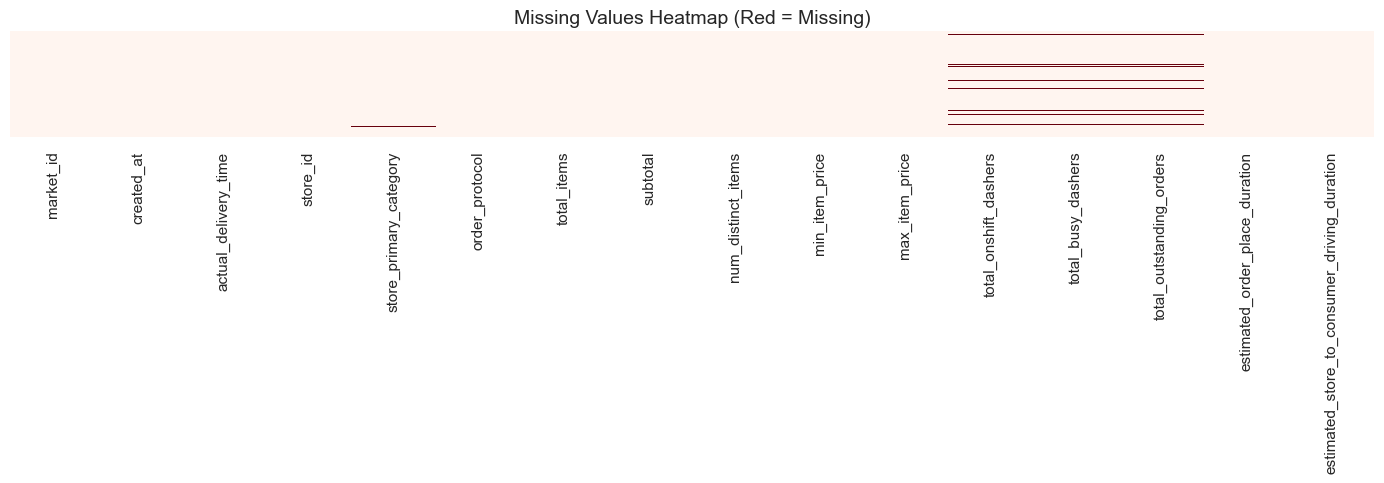

✅ Saved to outputs/figures/


In [9]:
# ── CELL 9: Missing Values Heatmap ───────────────────────────────────
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='Reds')
plt.title('Missing Values Heatmap (Red = Missing)', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/01_missing_values.png', dpi=150)
plt.show()
print('✅ Saved to outputs/figures/')

Numeric columns found: ['market_id', 'store_id', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration']


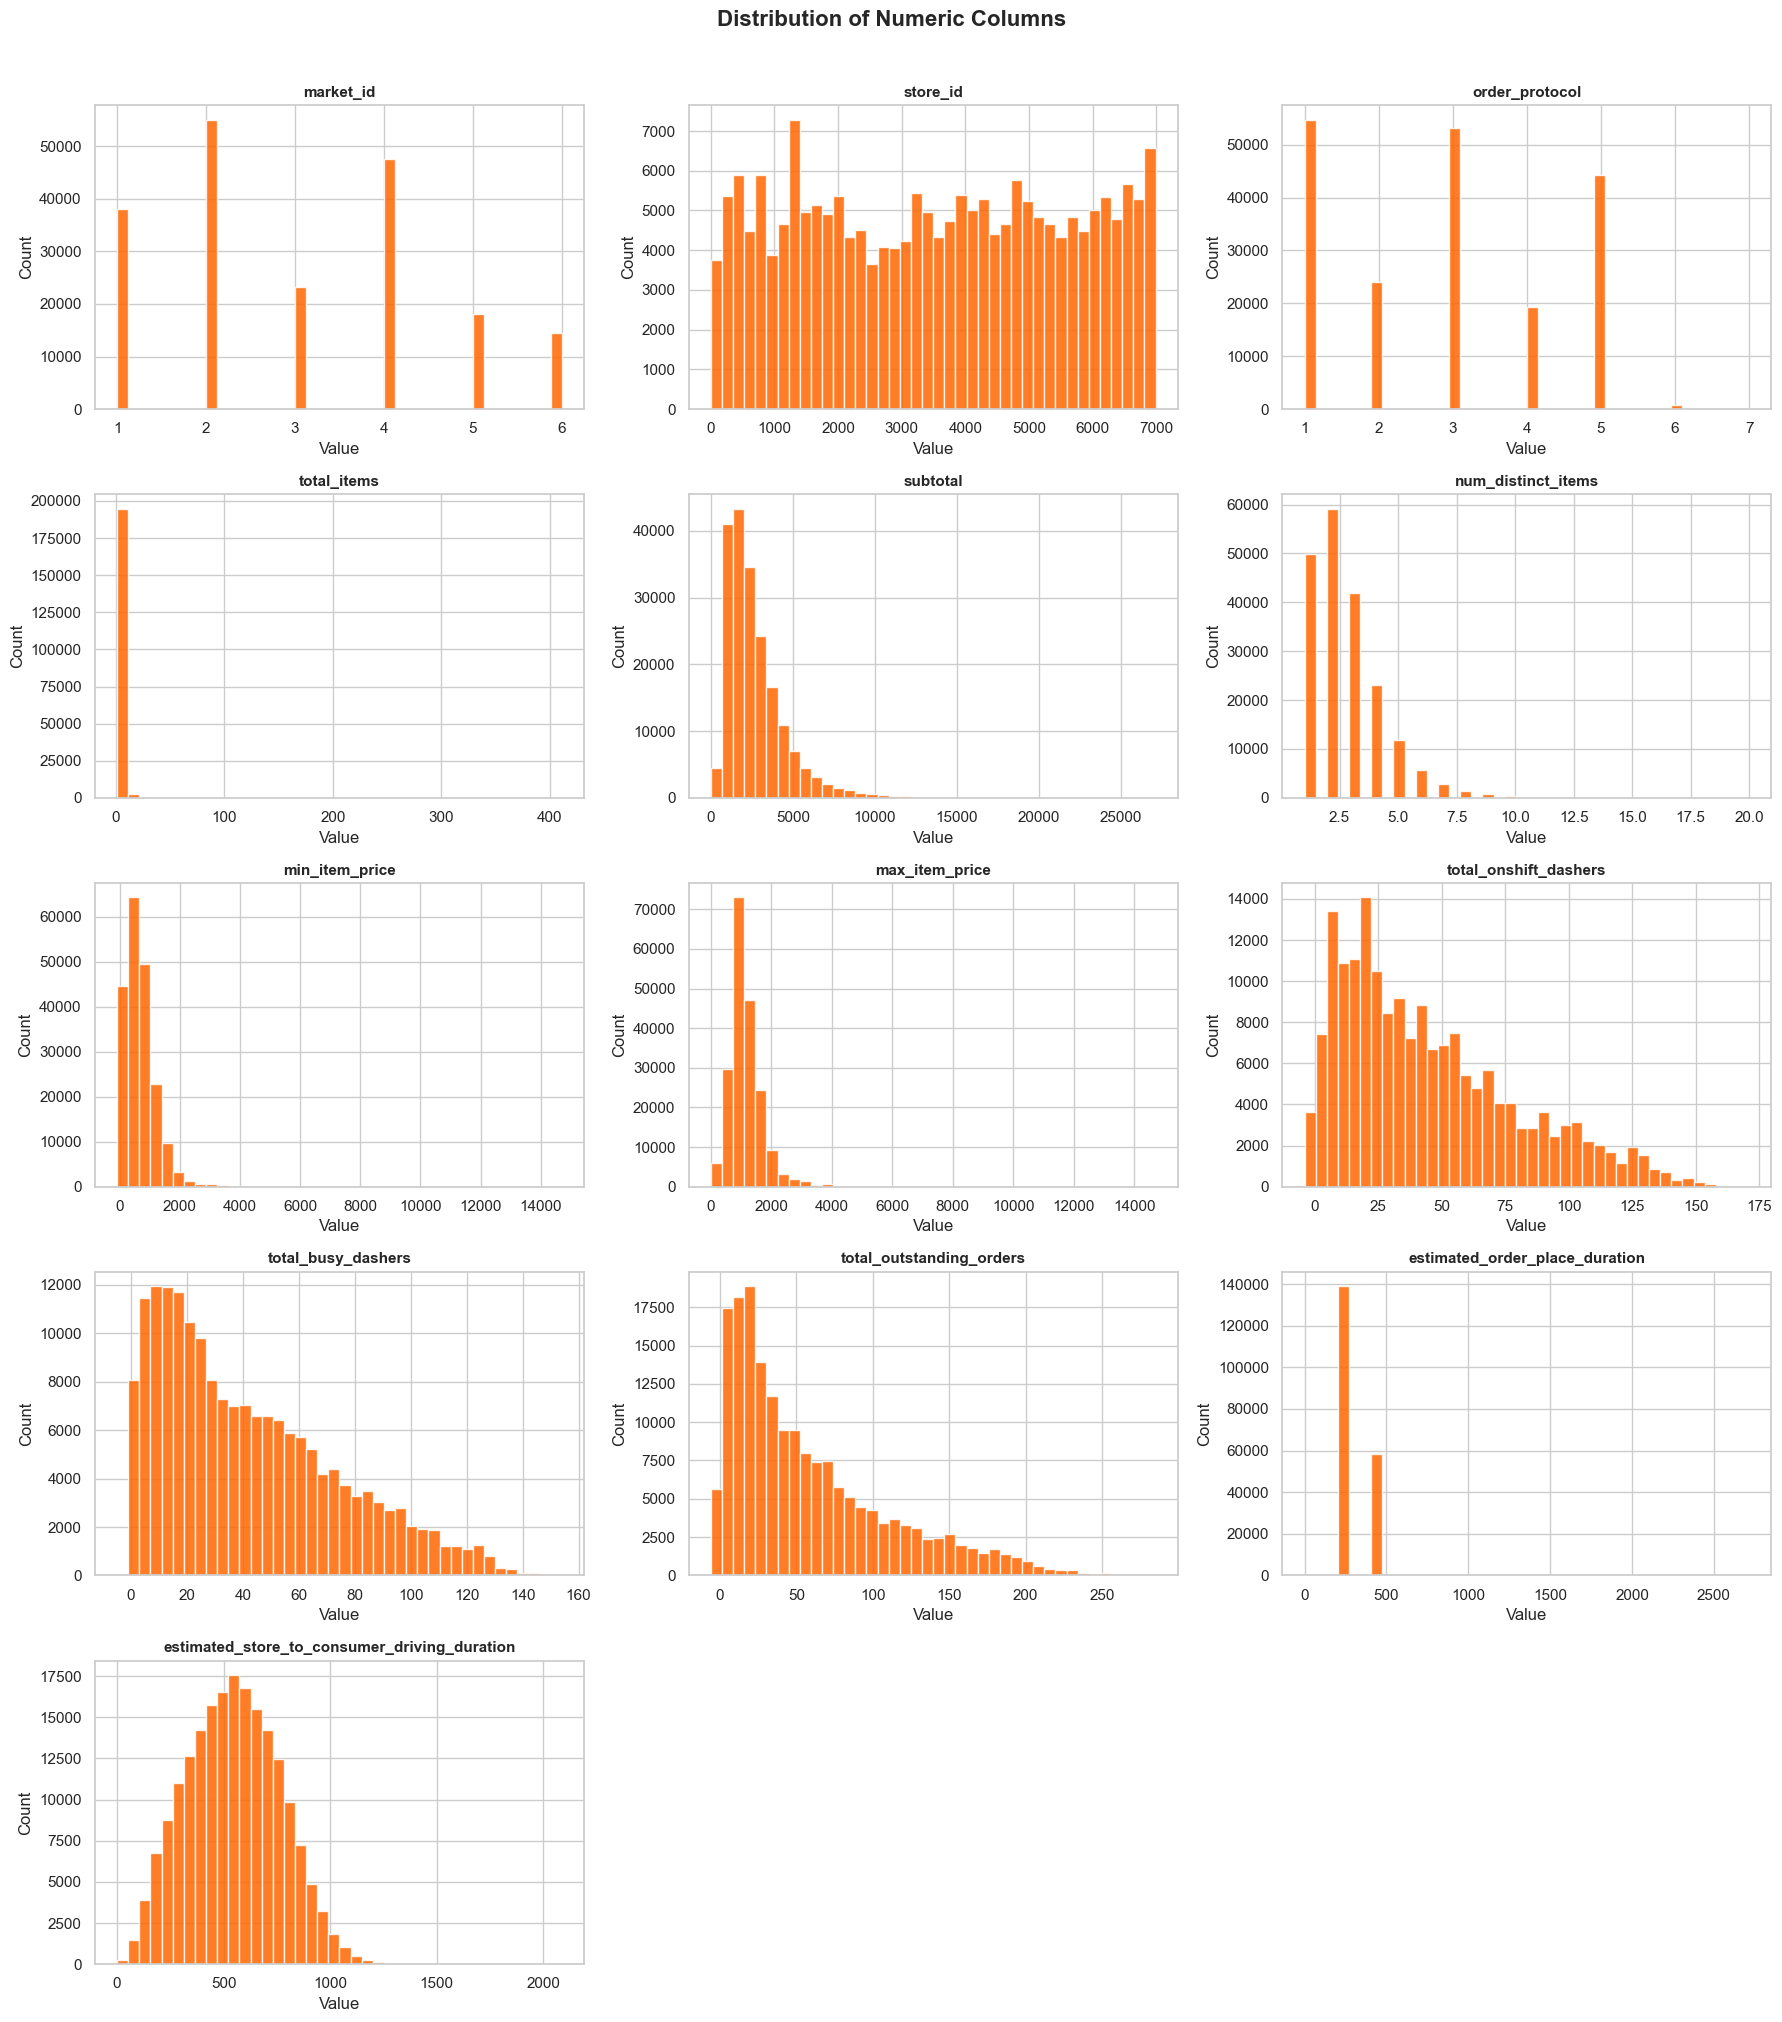

✅ Saved to outputs/figures/


In [10]:
# ── CELL 10: Distribution of Numeric Columns ─────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns found: {numeric_cols}')

n = len(numeric_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='#FF6600', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Columns', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to outputs/figures/')

In [11]:
# ── CELL 11: Categorical Columns Overview ────────────────────────────
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {cat_cols}\n')

for col in cat_cols:
    print(f'\n🔹 {col} — {df[col].nunique()} unique values')
    print(df[col].value_counts().head(10))

Categorical columns: ['created_at', 'actual_delivery_time', 'store_primary_category']


🔹 created_at — 180985 unique values
created_at
2015-01-24 01:56:33    6
2015-02-11 19:50:43    6
2015-02-08 02:20:03    5
2015-02-16 01:48:11    5
2015-01-31 01:41:10    5
2015-02-11 19:51:06    5
2015-02-11 19:50:41    5
2015-02-11 19:48:02    4
2015-02-14 02:00:10    4
2015-02-12 01:59:15    4
Name: count, dtype: int64

🔹 actual_delivery_time — 178110 unique values
actual_delivery_time
2015-02-16 03:51:49    5
2015-02-05 03:10:31    5
2015-01-24 03:41:03    5
2015-02-01 03:44:13    5
2015-02-12 03:14:14    5
2015-02-08 04:09:25    5
2015-02-11 20:40:45    5
2015-02-09 04:22:18    4
2015-02-03 04:00:43    4
2015-02-09 01:17:10    4
Name: count, dtype: int64

🔹 store_primary_category — 74 unique values
store_primary_category
american    19399
pizza       17321
mexican     17099
burger      10958
sandwich    10060
chinese      9421
japanese     9196
dessert      8773
fast         7372
indian       73

C:\Users\divya\AppData\Local\Temp\ipykernel_32516\2624214855.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


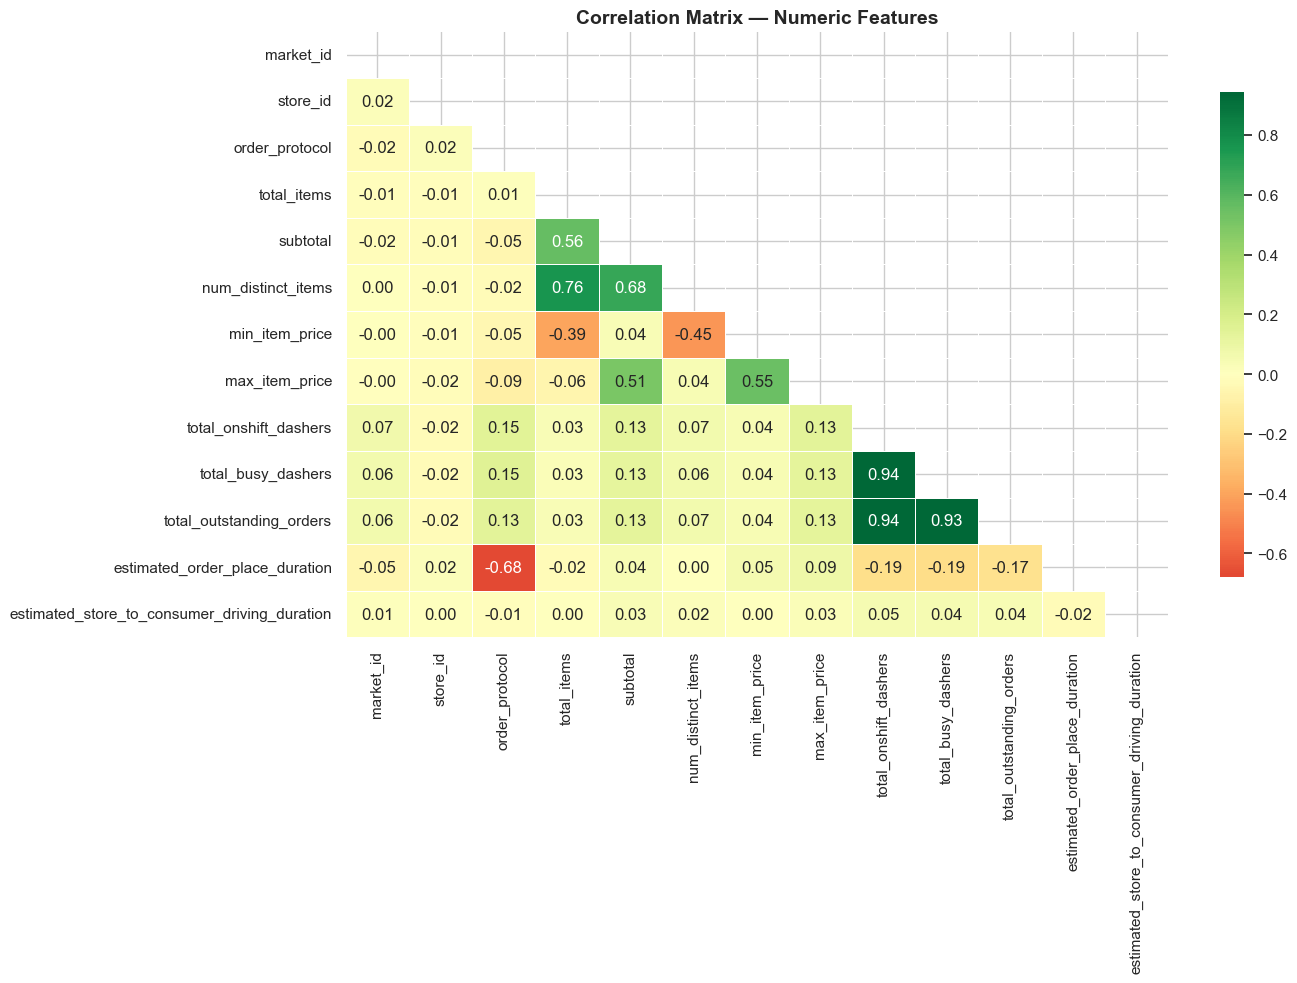

✅ Saved to outputs/figures/


In [12]:
# ── CELL 12: Correlation Matrix ───────────────────────────────────────
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_correlation_matrix.png', dpi=150)
plt.show()
print('✅ Saved to outputs/figures/')